<img src=https://i.imgur.com/WKQ0nH2.jpg height=350>

# Setup and Context


### Introduction

Welcome to Boston Massachusetts in the 1970s! Suppose I'm working for a real estate development company. The company wants to value any residential project before they start. I am tasked with building a model that can provide a price estimate based on a home's characteristics like:
* The number of rooms
* The distance to employment centres
* How rich or poor the area is
* How many students there are per teacher in local schools etc

<img src=https://i.imgur.com/WfUSSP7.png height=350>

To accomplish the task I will:

1. Analyse and explore the Boston house price data
2. Split my data for training and testing
3. Run a Multivariable Regression
4. Evaluate how my model's coefficients and residuals
5. Use data transformation to improve my model performance
6. Use my model to estimate a property price

### Upgrade plotly (only Google Colab Notebook)

Google Colab may not be running the latest version of plotly. If you're working in Google Colab, uncomment the line below, run the cell, and restart your notebook server.

In [ ]:
# %pip install --upgrade plotly

###  Import Statements


In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

### Notebook Presentation

In [ ]:
pd.options.display.float_format = '{:,.2f}'.format

# Load the Data

The first column in the .csv file just has the row numbers, so it will be used as the index.

In [ ]:
data = pd.read_csv('boston.csv', index_col=0)

### Understand the Boston House Price Dataset

---------------------------

**Characteristics:**  

    :Number of Instances: 506

    :Number of Attributes: 13 numeric/categorical predictive. The Median Value (attribute 14) is the target.

    :Attribute Information (in order):
        1. CRIM     per capita crime rate by town
        2. ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        3. INDUS    proportion of non-retail business acres per town
        4. CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        5. NOX      nitric oxides concentration (parts per 10 million)
        6. RM       average number of rooms per dwelling
        7. AGE      proportion of owner-occupied units built prior to 1940
        8. DIS      weighted distances to five Boston employment centres
        9. RAD      index of accessibility to radial highways
        10. TAX      full-value property-tax rate per $10,000
        11. PTRATIO  pupil-teacher ratio by town
        12. B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
        13. LSTAT    % lower status of the population
        14. PRICE     Median value of owner-occupied homes in $1000's
        
    :Missing Attribute Values: None

    :Creator: Harrison, D. and Rubinfeld, D.L.

This is a copy of [UCI ML housing dataset](https://archive.ics.uci.edu/ml/machine-learning-databases/housing/). This dataset was taken from the StatLib library which is maintained at Carnegie Mellon University. You can find the [original research paper here](https://deepblue.lib.umich.edu/bitstream/handle/2027.42/22636/0000186.pdf?sequence=1&isAllowed=y).


# Preliminary Data Exploration 🔎

* What is the shape of `data`?
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

In [ ]:
# What is the shape of data?
# How many rows and columns does it have?
print(f'The shape of the data is {data.shape[0]} columns and {data.shape[1]} rows')
print(f'Column names are: {data.columns}')


The shape of the data is 506 columns and 14 rows
Column names are: Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'PRICE'],
      dtype='object')


In [ ]:
# Are there any NaN values or duplicates?
data.isna().any().sum()
data.duplicated().sum()


np.int64(0)

## Data Cleaning - Check for Missing Values and Duplicates

In [ ]:
data.duplicated(subset=data.columns.drop("PRICE")).sum()



np.int64(0)

In [ ]:
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.01,18.00,2.31,0.00,0.54,6.58,65.20,4.09,1.00,296.00,15.30,396.90,4.98,24.00
1,0.03,0.00,7.07,0.00,0.47,6.42,78.90,4.97,2.00,242.00,17.80,396.90,9.14,21.60
2,0.03,0.00,7.07,0.00,0.47,7.18,61.10,4.97,2.00,242.00,17.80,392.83,4.03,34.70
3,0.03,0.00,2.18,0.00,0.46,7.00,45.80,6.06,3.00,222.00,18.70,394.63,2.94,33.40
4,0.07,0.00,2.18,0.00,0.46,7.15,54.20,6.06,3.00,222.00,18.70,396.90,5.33,36.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06,0.00,11.93,0.00,0.57,6.59,69.10,2.48,1.00,273.00,21.00,391.99,9.67,22.40
502,0.05,0.00,11.93,0.00,0.57,6.12,76.70,2.29,1.00,273.00,21.00,396.90,9.08,20.60
503,0.06,0.00,11.93,0.00,0.57,6.98,91.00,2.17,1.00,273.00,21.00,396.90,5.64,23.90
504,0.11,0.00,11.93,0.00,0.57,6.79,89.30,2.39,1.00,273.00,21.00,393.45,6.48,22.00


In [ ]:
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.01,18.00,2.31,0.00,0.54,6.58,65.20,4.09,1.00,296.00,15.30,396.90,4.98,24.00
1,0.03,0.00,7.07,0.00,0.47,6.42,78.90,4.97,2.00,242.00,17.80,396.90,9.14,21.60
2,0.03,0.00,7.07,0.00,0.47,7.18,61.10,4.97,2.00,242.00,17.80,392.83,4.03,34.70
3,0.03,0.00,2.18,0.00,0.46,7.00,45.80,6.06,3.00,222.00,18.70,394.63,2.94,33.40
4,0.07,0.00,2.18,0.00,0.46,7.15,54.20,6.06,3.00,222.00,18.70,396.90,5.33,36.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06,0.00,11.93,0.00,0.57,6.59,69.10,2.48,1.00,273.00,21.00,391.99,9.67,22.40
502,0.05,0.00,11.93,0.00,0.57,6.12,76.70,2.29,1.00,273.00,21.00,396.90,9.08,20.60
503,0.06,0.00,11.93,0.00,0.57,6.98,91.00,2.17,1.00,273.00,21.00,396.90,5.64,23.90
504,0.11,0.00,11.93,0.00,0.57,6.79,89.30,2.39,1.00,273.00,21.00,393.45,6.48,22.00


## Descriptive Statistics

* How many students are there per teacher on average?
* What is the average price of a home in the dataset?
* What is the `CHAS` feature?
* What are the minimum and the maximum value of the `CHAS` and why?
* What is the maximum and the minimum number of rooms per dwelling in the dataset?

In [ ]:
# How many students are there per teacher on average?
print(f'There are {data.PTRATIO.mean():.0f} students per teacher on average.')

# What is the average price of a home in the dataset?
print(f'The average price of a home in the dataset is ${data.PRICE.mean() * 1000:.0f}')

# What is the CHAS feature?
print(f'CHAS 1 means the area borders the Charles River.\nCHAS 0 means the area does NOT border the river.')

# What are the minimum and the maximum value of the CHAS and why?
print(f"It's 0 and 1. Because it's a binary variable.")

# What is the maximum and the minimum number of rooms per dwelling in the dataset?
print(f"The maximum number of rooms is {data.RM.max():.0f} and the minimum number of rooms is {data.RM.min():.0f}")

There are 18 students per teacher on average.
The average price of a home in the dataset is $22533
CHAS 1 means the area borders the Charles River.
CHAS 0 means the area does NOT border the river.
It's 0 and 1. Because it's a binary variable.
The maximum number of rooms is 9 and the minimum number of rooms is 4


In [ ]:
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.01,18.00,2.31,0.00,0.54,6.58,65.20,4.09,1.00,296.00,15.30,396.90,4.98,24.00
1,0.03,0.00,7.07,0.00,0.47,6.42,78.90,4.97,2.00,242.00,17.80,396.90,9.14,21.60
2,0.03,0.00,7.07,0.00,0.47,7.18,61.10,4.97,2.00,242.00,17.80,392.83,4.03,34.70
3,0.03,0.00,2.18,0.00,0.46,7.00,45.80,6.06,3.00,222.00,18.70,394.63,2.94,33.40
4,0.07,0.00,2.18,0.00,0.46,7.15,54.20,6.06,3.00,222.00,18.70,396.90,5.33,36.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06,0.00,11.93,0.00,0.57,6.59,69.10,2.48,1.00,273.00,21.00,391.99,9.67,22.40
502,0.05,0.00,11.93,0.00,0.57,6.12,76.70,2.29,1.00,273.00,21.00,396.90,9.08,20.60
503,0.06,0.00,11.93,0.00,0.57,6.98,91.00,2.17,1.00,273.00,21.00,396.90,5.64,23.90
504,0.11,0.00,11.93,0.00,0.57,6.79,89.30,2.39,1.00,273.00,21.00,393.45,6.48,22.00


In [ ]:
data.RAD.max()

24.0

## Visualise the Features

 Having looked at some descriptive statistics, I will visualise the data for my model. I will use [Seaborn's `.displot()`](https://seaborn.pydata.org/generated/seaborn.displot.html#seaborn.displot) to create a bar chart and superimpose the Kernel Density Estimate (KDE) for the following variables:
* PRICE: The home price in thousands.
* RM: the average number of rooms per owner unit.
* DIS: the weighted distance to the 5 Boston employment centres i.e., the estimated length of the commute.
* RAD: the index of accessibility to highways.

I will try setting the `aspect` parameter to `2` for a better picture.

What do you we notice in the distributions of the data?

#### House Prices 💰

Text(0.5, 1.0, 'The home price in thousands')

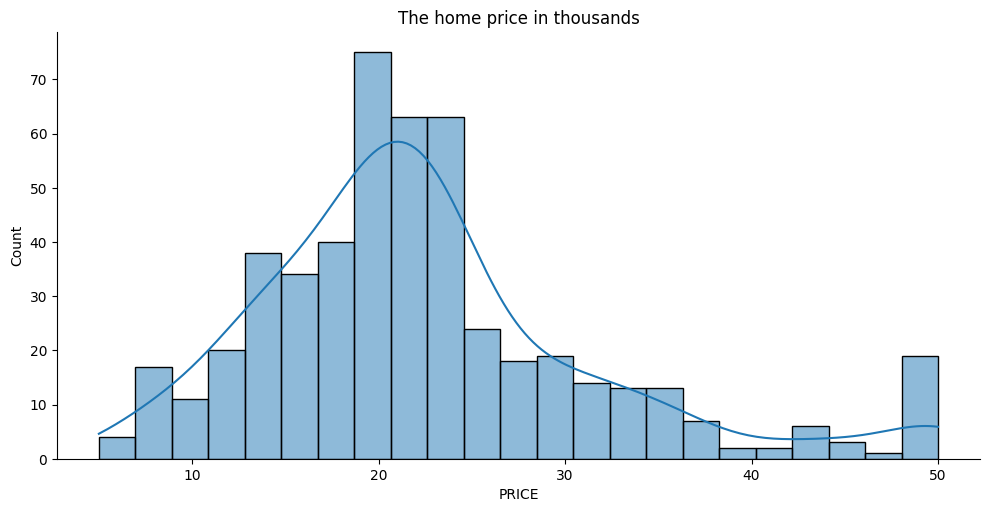

In [ ]:
b_chart_house_prices = sns.displot(data=data, x="PRICE", kde=True, aspect=2)
plt.title('The home price in thousands')

#### Distance to Employment - Length of Commute 🚗

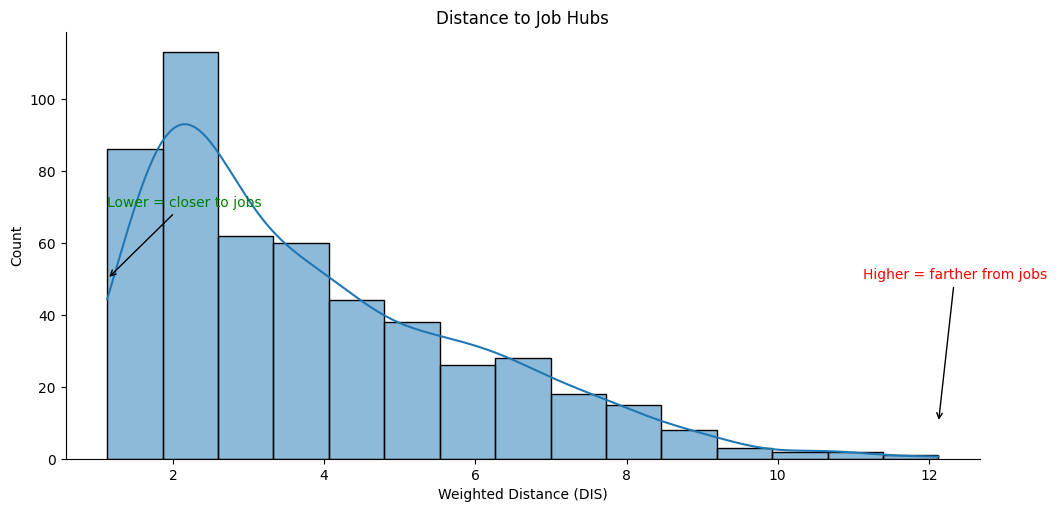

In [ ]:

b_chart_dist_emp = sns.displot(data=data, x="DIS", kde=True, aspect=2)

plt.title('Distance to Job Hubs')
plt.xlabel('Weighted Distance (DIS)')
plt.ylabel('Count')

plt.annotate('Lower = closer to jobs', xy=(data["DIS"].min(), 50), xytext=(data["DIS"].min(), 70),
             arrowprops=dict(facecolor='green', arrowstyle='->'), color='green', fontsize=10)
plt.annotate('Higher = farther from jobs', xy=(data["DIS"].max(), 10), xytext=(data["DIS"].max()-1, 50),
             arrowprops=dict(facecolor='red', arrowstyle='->'), color='red', fontsize=10)

plt.show()


#### Number of Rooms

Text(0.5, 1.0, 'The average number of rooms per unit')

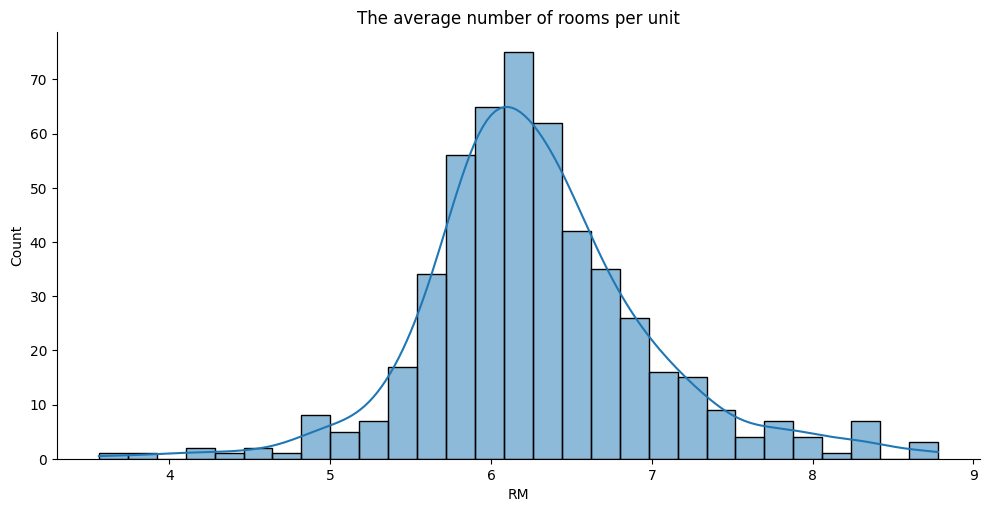

In [ ]:
b_chart_num_rooms= sns.displot(data=data, x="RM", kde=True, aspect=2)

plt.title('The average number of rooms per unit')

#### Access to Highways 🛣

Text(19.0, 20, 'Higher = excellent access')

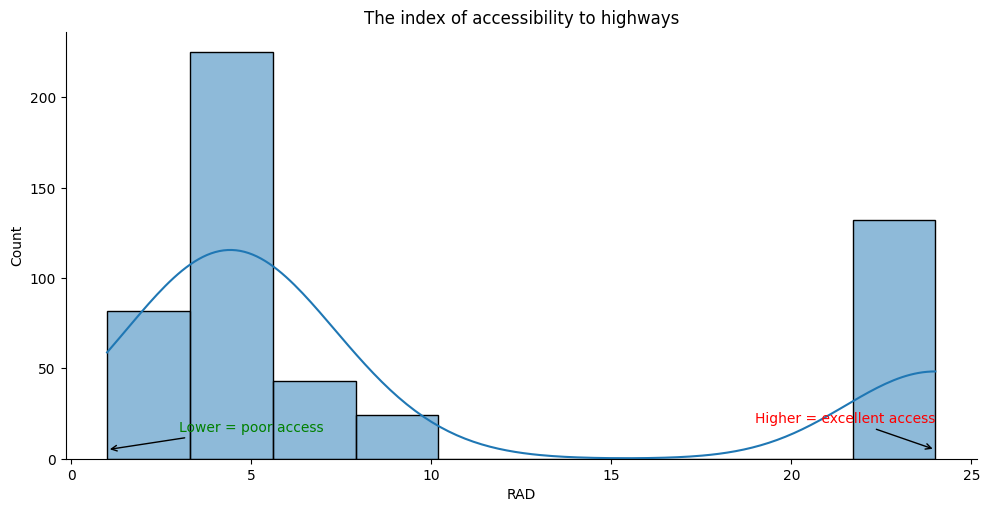

In [ ]:
data
b_chart_highways= sns.displot(data=data, x="RAD", kde=True, aspect=2)

plt.title('The index of accessibility to highways')

plt.annotate('Lower = poor access',
             xy=(data["RAD"].min(), 5), xytext=(data["RAD"].min()+2, 15),
             arrowprops=dict(facecolor='green', arrowstyle='->'), color='green', fontsize=10)

plt.annotate('Higher = excellent access',
             xy=(data["RAD"].max(), 5), xytext=(data["RAD"].max()-5, 20),
             arrowprops=dict(facecolor='red', arrowstyle='->'), color='red', fontsize=10)


#### Next to the River? ⛵️

I will create a bar chart with plotly for CHAS to show many more homes are away from the river versus next to it. The bar chart should look something like this:

<img src=https://i.imgur.com/AHwoQ6l.png height=350>

You can make your life easier by providing a list of values for the x-axis (e.g., `x=['No', 'Yes']`)

In [ ]:
fig = px.bar(
    data.CHAS,
    x=['No', 'Yes'],
    y=data.CHAS.value_counts(),
    color=['No', 'Yes'],
    color_discrete_sequence=['#f5d547', '#1f2c56'],
    title="Homes Next to the Charles River (CHAS)",
    labels={"x": "Property Next to River?",
            "y": "Number of Homes"},
    )

fig.update_layout(showlegend=False)
fig.show()


In [ ]:
  data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.01,18.00,2.31,0.00,0.54,6.58,65.20,4.09,1.00,296.00,15.30,396.90,4.98,24.00
1,0.03,0.00,7.07,0.00,0.47,6.42,78.90,4.97,2.00,242.00,17.80,396.90,9.14,21.60
2,0.03,0.00,7.07,0.00,0.47,7.18,61.10,4.97,2.00,242.00,17.80,392.83,4.03,34.70
3,0.03,0.00,2.18,0.00,0.46,7.00,45.80,6.06,3.00,222.00,18.70,394.63,2.94,33.40
4,0.07,0.00,2.18,0.00,0.46,7.15,54.20,6.06,3.00,222.00,18.70,396.90,5.33,36.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06,0.00,11.93,0.00,0.57,6.59,69.10,2.48,1.00,273.00,21.00,391.99,9.67,22.40
502,0.05,0.00,11.93,0.00,0.57,6.12,76.70,2.29,1.00,273.00,21.00,396.90,9.08,20.60
503,0.06,0.00,11.93,0.00,0.57,6.98,91.00,2.17,1.00,273.00,21.00,396.90,5.64,23.90
504,0.11,0.00,11.93,0.00,0.57,6.79,89.30,2.39,1.00,273.00,21.00,393.45,6.48,22.00


<img src=https://i.imgur.com/b5UaBal.jpg height=350>

# Understand the Relationships in the Data

### Run a Pair Plot

There might be some relationships in the data that I should know about. Before I run the code, I will make some predictions:

* What would I expect the relationship to be between pollution (NOX) and the distance to employment (DIS)?
* What kind of relationship do I expect between the number of rooms (RM) and the home value (PRICE)?
* What about the amount of poverty in an area (LSTAT) and home prices?

I will run a [Seaborn `.pairplot()`](https://seaborn.pydata.org/generated/seaborn.pairplot.html?highlight=pairplot#seaborn.pairplot) to visualise all the relationships at the same time. After it's finished, I will check my intuition regarding the questions above on the `pairplot`.

In [ ]:
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.01,18.00,2.31,0.00,0.54,6.58,65.20,4.09,1.00,296.00,15.30,396.90,4.98,24.00
1,0.03,0.00,7.07,0.00,0.47,6.42,78.90,4.97,2.00,242.00,17.80,396.90,9.14,21.60
2,0.03,0.00,7.07,0.00,0.47,7.18,61.10,4.97,2.00,242.00,17.80,392.83,4.03,34.70
3,0.03,0.00,2.18,0.00,0.46,7.00,45.80,6.06,3.00,222.00,18.70,394.63,2.94,33.40
4,0.07,0.00,2.18,0.00,0.46,7.15,54.20,6.06,3.00,222.00,18.70,396.90,5.33,36.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06,0.00,11.93,0.00,0.57,6.59,69.10,2.48,1.00,273.00,21.00,391.99,9.67,22.40
502,0.05,0.00,11.93,0.00,0.57,6.12,76.70,2.29,1.00,273.00,21.00,396.90,9.08,20.60
503,0.06,0.00,11.93,0.00,0.57,6.98,91.00,2.17,1.00,273.00,21.00,396.90,5.64,23.90
504,0.11,0.00,11.93,0.00,0.57,6.79,89.30,2.39,1.00,273.00,21.00,393.45,6.48,22.00


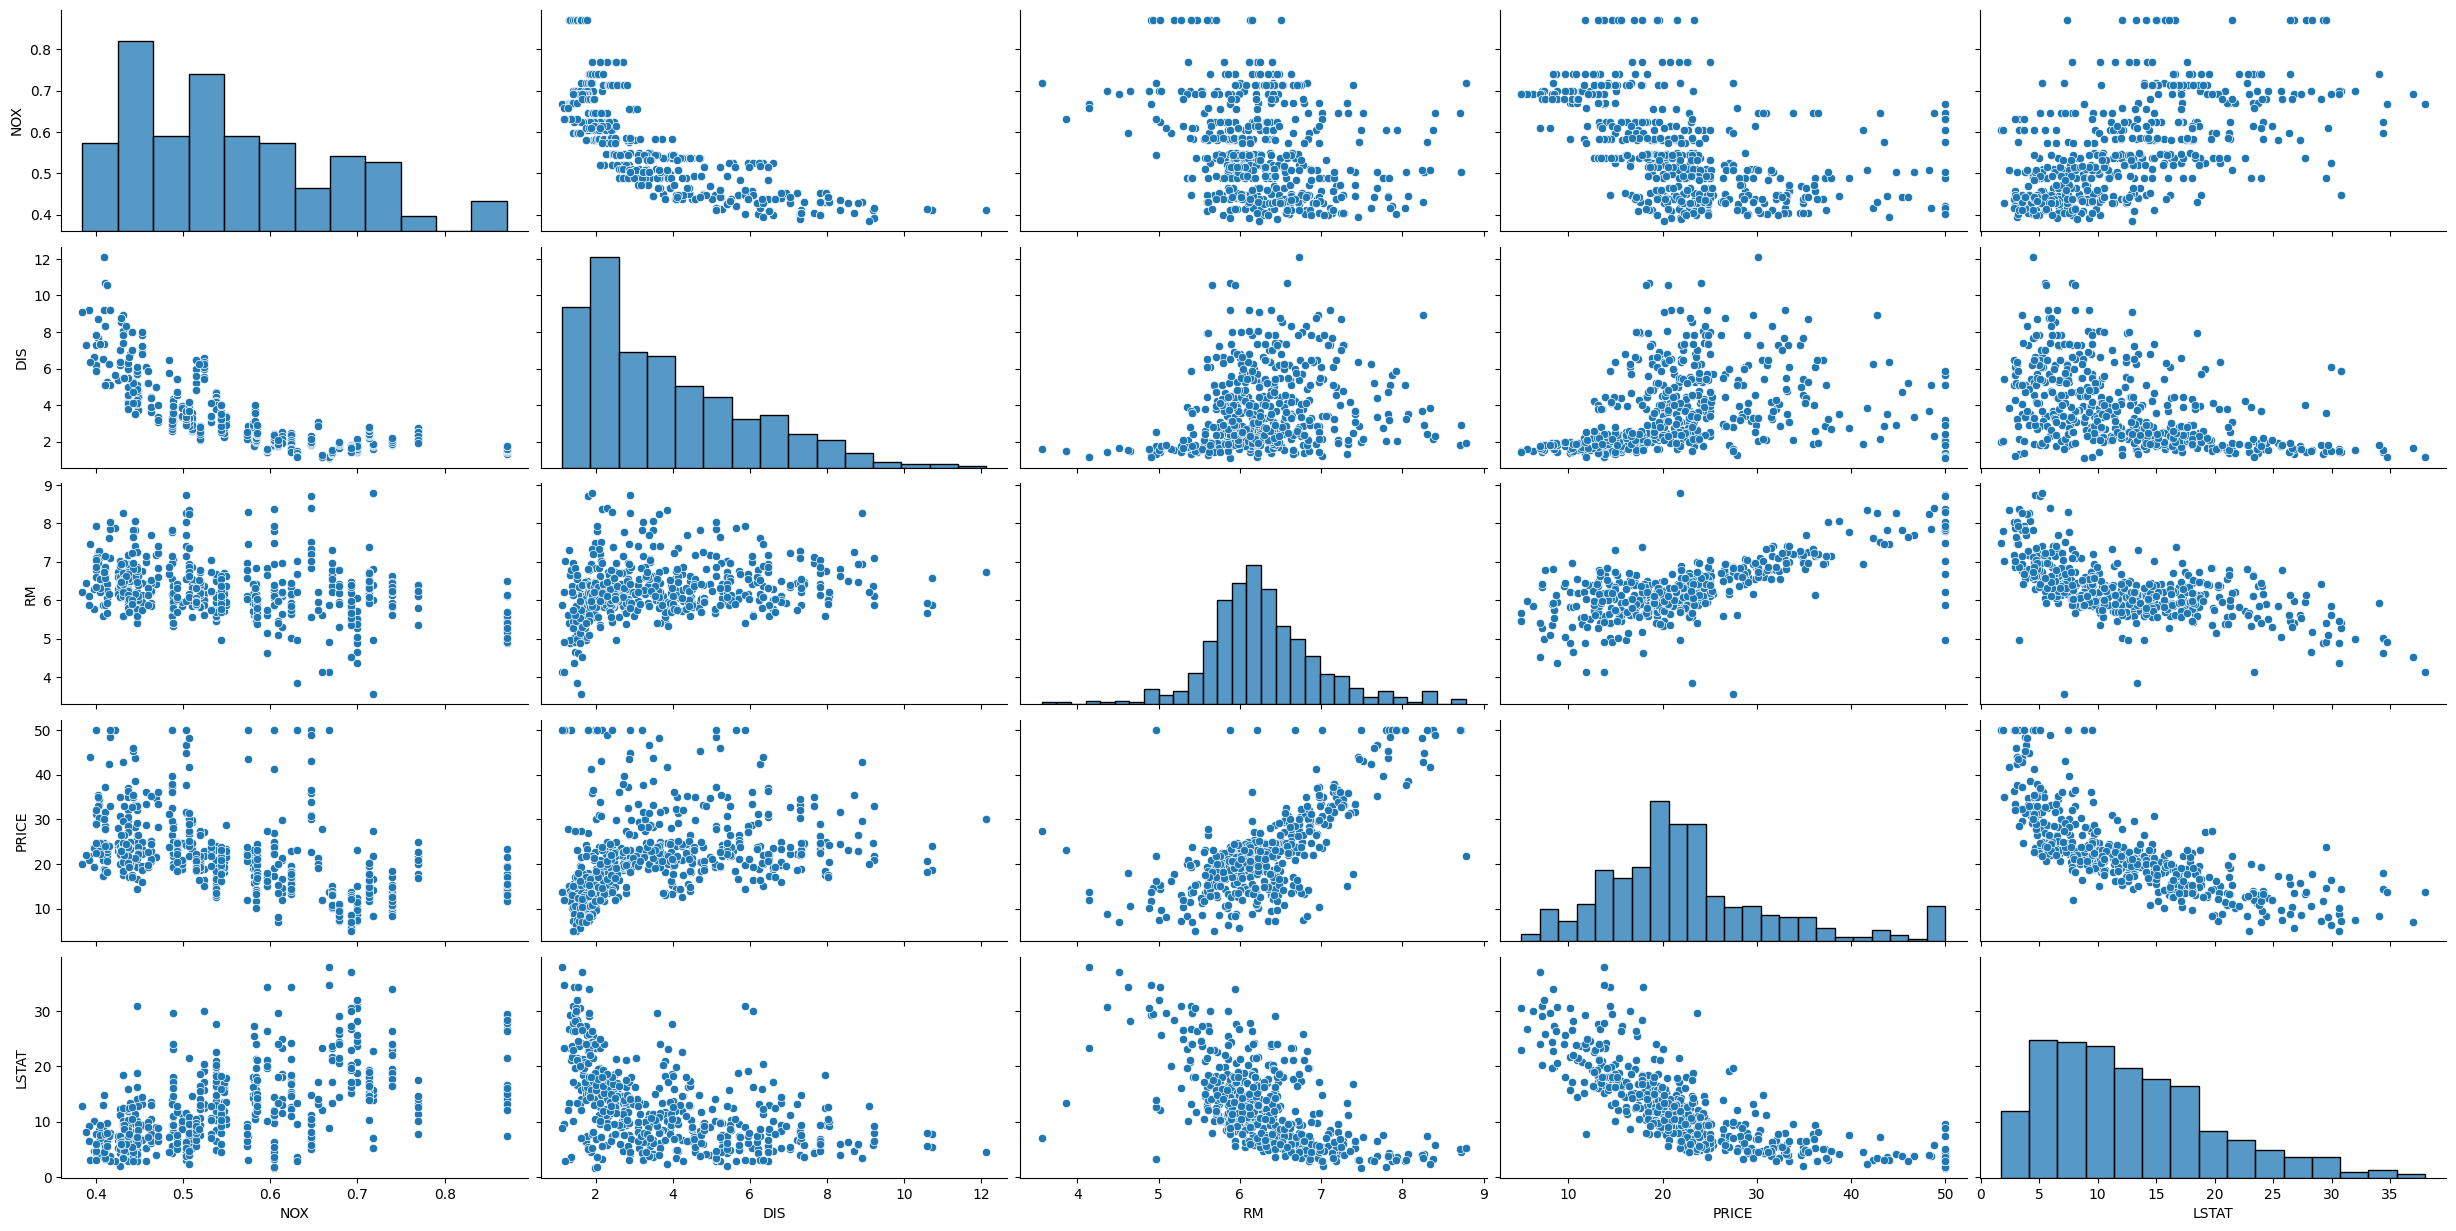

In [ ]:
sns.pairplot(data, vars=['NOX', 'DIS', 'RM', 'PRICE', 'LSTAT'], aspect=2)

I will use [Seaborn's `.jointplot()`](https://seaborn.pydata.org/generated/seaborn.jointplot.html) to look at some of the relationships in more detail. Create a jointplot for:

* DIS and NOX
* INDUS vs NOX
* LSTAT vs RM
* LSTAT vs PRICE
* RM vs PRICE



#### Distance from Employment vs. Pollution

I will compare DIS (Distance from employment) with NOX (Nitric Oxide Pollution) using Seaborn's `.jointplot()`. Does pollution go up or down as the distance increases?

The farther a home is from employment hubs, the cleaner the air.


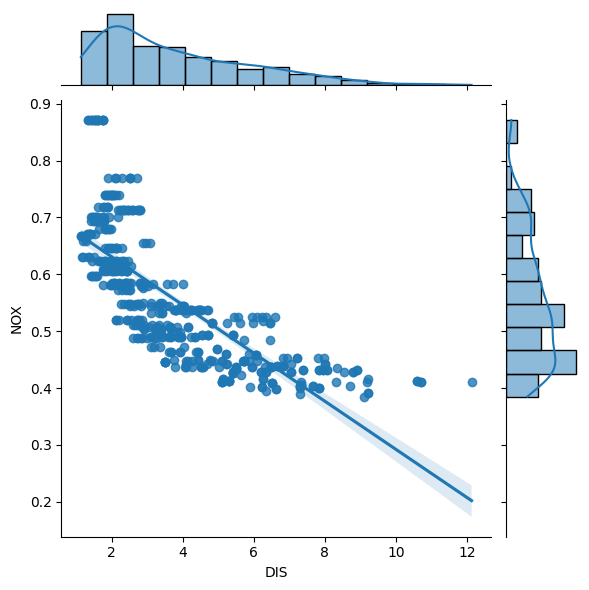

In [ ]:
sns.jointplot(data=data, x='DIS', y='NOX', kind='reg')
print('The farther a home is from employment hubs, the cleaner the air.')


#### Proportion of Non-Retail Industry 🏭🏭🏭 versus Pollution

I will compare INDUS (the proportion of non-retail industry i.e., factories) with NOX (Nitric Oxide Pollution) using Seaborn's `.jointplot()`. Does pollution go up or down as there is a higher proportion of industry?

There is a strong positive relationship between INDUS and NOX.
Areas with more industrial land tend to have significantly higher pollution levels.


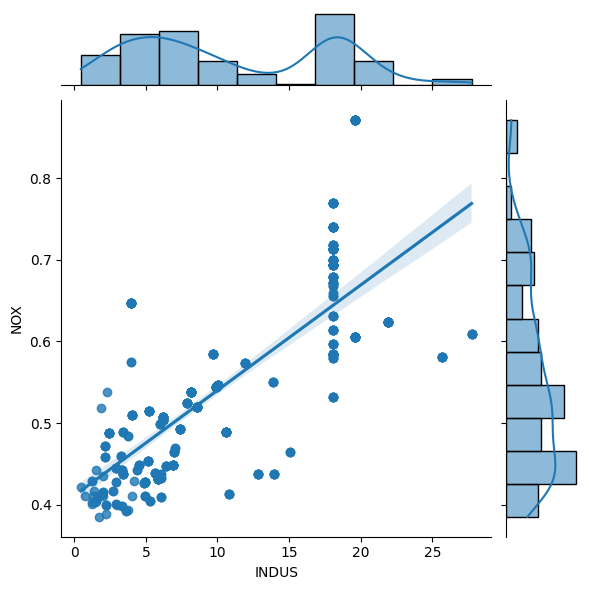

In [ ]:
sns.jointplot(data, x='INDUS', y='NOX', kind='reg')
print('There is a strong positive relationship between INDUS and NOX.\nAreas with more industrial land tend to have significantly higher pollution levels.')

#### % of Lower Income Population vs Average Number of Rooms

I will compare LSTAT (proportion of lower-income population) with RM (number of rooms) using Seaborn's `.jointplot()`. How does the number of rooms per dwelling vary with the poverty of area? Do homes have more or fewer rooms when LSTAT is low?

Yes. When LSTAT (powerty) is low, homes have MORE rooms.
When LSTAT is high, homes have FEWER rooms.


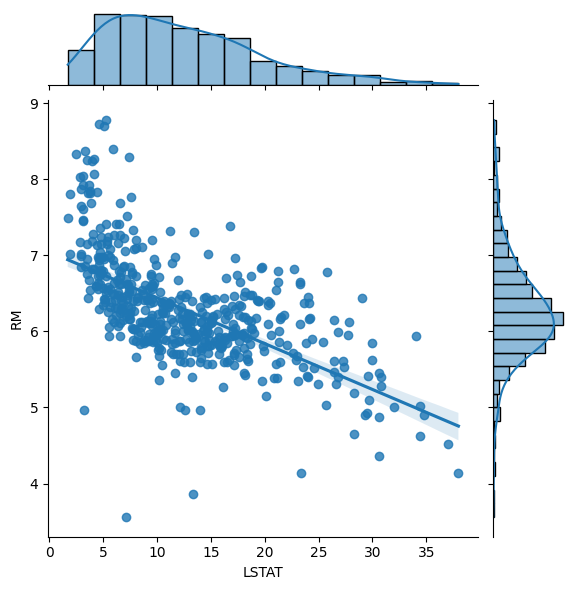

In [ ]:
sns.jointplot(data, x='LSTAT', y='RM', kind='reg')
print('Yes. When LSTAT (powerty) is low, homes have MORE rooms.\nWhen LSTAT is high, homes have FEWER rooms.')

#### % of Lower Income Population versus Home Price

I will compare LSTAT with PRICE using Seaborn's `.jointplot()`. How does the proportion of the lower-income population in an area affect home prices?

Yes — more poverty → cheaper houses.
Less poverty → more expensive houses.


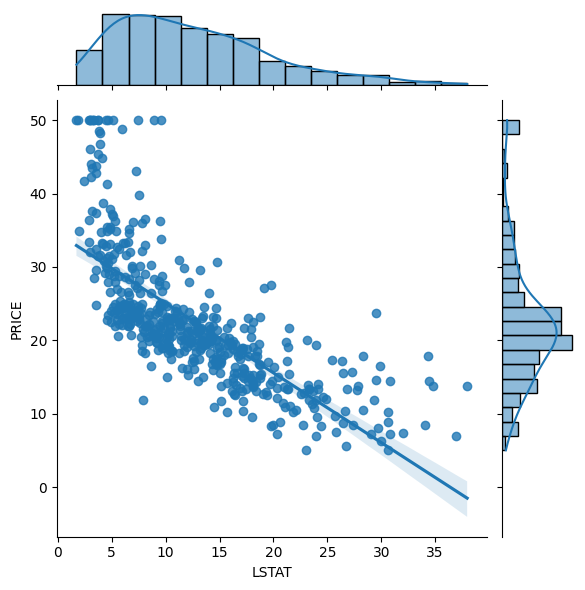

In [ ]:
sns.jointplot(data, x='LSTAT', y='PRICE', kind='reg')
print('Yes — more poverty → cheaper houses.\nLess poverty → more expensive houses.')

#### Number of Rooms versus Home Value

I will compare RM (number of rooms) with PRICE using Seaborn's `.jointplot()`. You can probably guess how the number of rooms affects home prices. 😊

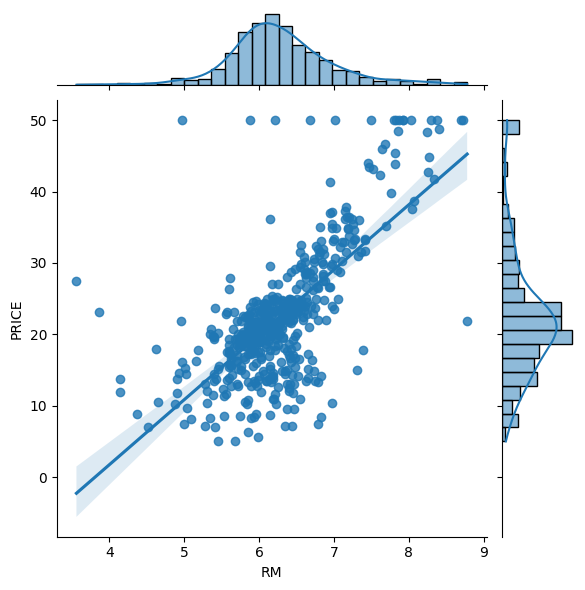

In [ ]:
sns.jointplot(data, x='RM', y='PRICE', kind='reg')

# Split Training & Test Dataset

We *can't* use all 506 entries in our dataset to train our model. The reason is that we want to evaluate our model on data that it hasn't seen yet (i.e., out-of-sample data). That way we can get a better idea of its performance in the real world.

* Import the [`train_test_split()` function](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) from sklearn
* Create 4 subsets: X_train, X_test, y_train, y_test
* Split the training and testing data roughly 80/20.
* To get the same random split every time you run your notebook use `random_state=10`. This helps us get the same results every time and avoid confusion while we're learning.


Remember, my **target** is my home PRICE, and my **features** are all the other columns I'll use to predict the price.


In [ ]:
X = data.drop("PRICE", axis=1)
y = data["PRICE"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=10
)
X_train

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
50,0.09,21.00,5.64,0.00,0.44,5.96,45.70,6.81,4.00,243.00,16.80,395.56,13.45
367,13.52,0.00,18.10,0.00,0.63,3.86,100.00,1.51,24.00,666.00,20.20,131.42,13.33
34,1.61,0.00,8.14,0.00,0.54,6.10,96.90,3.76,4.00,307.00,21.00,248.31,20.34
78,0.06,0.00,12.83,0.00,0.44,6.23,53.70,5.01,5.00,398.00,18.70,386.40,12.34
172,0.14,0.00,4.05,0.00,0.51,5.57,88.50,2.60,5.00,296.00,16.60,396.90,14.69
...,...,...,...,...,...,...,...,...,...,...,...,...,...
320,0.17,0.00,7.38,0.00,0.49,6.43,52.30,4.54,5.00,287.00,19.60,396.90,7.20
15,0.63,0.00,8.14,0.00,0.54,5.83,56.50,4.50,4.00,307.00,21.00,395.62,8.47
484,2.38,0.00,18.10,0.00,0.58,5.87,41.90,3.72,24.00,666.00,20.20,370.73,13.34
125,0.17,0.00,25.65,0.00,0.58,5.99,88.40,1.99,2.00,188.00,19.10,385.02,14.81


In [ ]:
y_train

,PRICE
50,19.70
367,23.10
34,13.50
78,21.20
172,23.10
...,...
320,23.80
15,19.90
484,20.60
125,21.40


# Multivariable Regression

Our Linear Regression model will have the following form:

$$ PR \hat ICE = \theta _0 + \theta _1 RM + \theta _2 NOX + \theta _3 DIS + \theta _4 CHAS ... + \theta _{13} LSTAT$$

### Run Regression

I will use sklearn to run the regression on the training dataset. How high is the r-squared for the regression on the training data?

In [ ]:
reg = LinearRegression().fit(X_train, y_train)
y_pred = reg.predict(X_test)
print(f"Coefficients: {reg.coef_}")
print(f"Intercept: {reg.intercept_}")
print(f"Score: {reg.score(X_train, y_train)}")
print(f"Predictions: {y_pred}")


Coefficients: [-1.28180656e-01  6.31981786e-02 -7.57627602e-03  1.97451452e+00
 -1.62719890e+01  3.10845625e+00  1.62922153e-02 -1.48301360e+00
  3.03988206e-01 -1.20820710e-02 -8.20305699e-01  1.14189890e-02
 -5.81626431e-01]
Intercept: 36.53305138282431
Score: 0.750121534530608
Predictions: [31.0789639  31.721694   30.87314928 22.28234976 18.85606115 16.47132499
 36.05004157 14.64032337 25.24078574 36.92073901 21.24395893 31.05887245
 27.83837442 33.90940352 33.94484713 40.02040311 24.14373978 23.32713796
 25.34120561 21.49039367 32.84083784 17.72022746 25.36791791 24.95097385
 32.39265827 20.42497001 19.33257493 16.97042135 38.61885431  0.99817403
 32.18145419 32.02985417 26.01208772 23.68917386 20.38030786 19.45806916
  3.46147073 34.9034939  26.98281534 27.54218642 33.89021463 29.7542196
 18.15540973 31.44609872 17.82446519 28.30204573 19.31527567 21.90113613
 37.88043957 16.3464837  24.68739442 19.29872222 24.46627252 33.91063878
 26.63876989 34.33425076 20.88039511 19.69421544 1

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 34.41396845313842
R2 Score: 0.6709339839115642


In [ ]:
print(y_pred[:5])


[31.0789639  31.721694   30.87314928 22.28234976 18.85606115]


In [ ]:
print(y_test[:5])


305   28.40
193   31.10
65    23.50
349   26.60
151   19.60
Name: PRICE, dtype: float64


In [ ]:
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.01,18.00,2.31,0.00,0.54,6.58,65.20,4.09,1.00,296.00,15.30,396.90,4.98,24.00
1,0.03,0.00,7.07,0.00,0.47,6.42,78.90,4.97,2.00,242.00,17.80,396.90,9.14,21.60
2,0.03,0.00,7.07,0.00,0.47,7.18,61.10,4.97,2.00,242.00,17.80,392.83,4.03,34.70
3,0.03,0.00,2.18,0.00,0.46,7.00,45.80,6.06,3.00,222.00,18.70,394.63,2.94,33.40
4,0.07,0.00,2.18,0.00,0.46,7.15,54.20,6.06,3.00,222.00,18.70,396.90,5.33,36.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06,0.00,11.93,0.00,0.57,6.59,69.10,2.48,1.00,273.00,21.00,391.99,9.67,22.40
502,0.05,0.00,11.93,0.00,0.57,6.12,76.70,2.29,1.00,273.00,21.00,396.90,9.08,20.60
503,0.06,0.00,11.93,0.00,0.57,6.98,91.00,2.17,1.00,273.00,21.00,396.90,5.64,23.90
504,0.11,0.00,11.93,0.00,0.57,6.79,89.30,2.39,1.00,273.00,21.00,393.45,6.48,22.00


### Evaluate the Coefficients of the Model

Here I do a check on my regression coefficients. The first thing to look for is if the coefficients have the expected sign (positive or negative).

I will print out the coefficients (the thetas in the equation above) for the features and put it in a DataFrame.

* I already saw that RM on its own had a positive relation to PRICE based on the scatter plot. Is RM's coefficient also positive?
* What is the sign on the LSAT coefficient? Does it match my intuition and the scatter plot above?
* Check the other coefficients. Do they have the expected sign?
* Based on the coefficients, how much more expensive is a room with 6 rooms compared to a room with 5 rooms? According to the model, what is the premium you would have to pay for an extra room?

In [ ]:
coef_df = pd.DataFrame(
    data=reg.coef_,
    index=X.columns,
    columns=['Coefficient']
)
coef_df


,Coefficient
CRIM,-0.13
ZN,0.06
INDUS,-0.01
CHAS,1.97
NOX,-16.27
RM,3.11
AGE,0.02
DIS,-1.48
RAD,0.30
TAX,-0.01


In [ ]:
# RM coefficient
rm_coef = coef_df.loc['RM'].values[0]
print(f"Is RM's coefficient positive? Yes. RM coefficient = {rm_coef:.2f}\n")

# LSTAT coefficient
lstat_coef = coef_df.loc['LSTAT'].values[0]
print(f"What is the sign of the LSTAT coefficient? It's {lstat_coef:.2f}, which is negative — matching the scatterplot and our intuition.\n")

# Other coefficients
print("Do the other coefficients have the expected signs? Yes.\n")

# Premium for an extra room
print(f"How much more expensive is a 6-room house compared to a 5-room house?")
print(f"According to the model, each additional room increases price by about ${rm_coef*1000:.0f}.\n")




Is RM's coefficient positive? Yes. RM coefficient = 3.11

What is the sign of the LSTAT coefficient? It's -0.58, which is negative — matching the scatterplot and our intuition.

Do the other coefficients have the expected signs? Yes.

How much more expensive is a 6-room house compared to a 5-room house?
According to the model, each additional room increases price by about $3108.



### Analyse the Estimated Values & Regression Residuals

The next step is to evaluate my regression. How good my regression is depends not only on the r-squared. It also depends on the **residuals** - the difference between the model's predictions ($\hat y_i$) and the true values ($y_i$) inside `y_train`.

```
predicted_values = regr.predict(X_train)
residuals = (y_train - predicted_values)
```

I will create two scatter plots.

The first plot should be actual values (`y_train`) against the predicted value values:

<img src=https://i.imgur.com/YMttBNV.png height=350>

The cyan line in the middle shows `y_train` against `y_train`. If the predictions had been 100% accurate then all the dots would be on this line. The further away the dots are from the line, the worse the prediction was. That makes the distance to the cyan line, our residuals 😊


The second plot should be the residuals against the predicted prices. Here's what I'm looking for:

<img src=https://i.imgur.com/HphsBsj.png height=350>



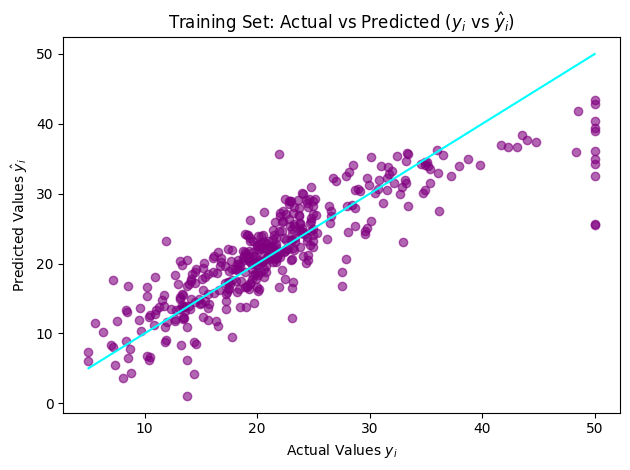

In [ ]:
predicted_values = reg.predict(X_train)
residuals = (y_train - predicted_values)

plt.scatter(y_train, predicted_values, color='purple', alpha=0.6)
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         color='cyan', linestyle='-')

plt.xlabel(r"Actual Values $y_i$")
plt.ylabel(r"Predicted Values $\hat{y}_i$")
plt.title(r"Training Set: Actual vs Predicted ($y_i$ vs $\hat{y}_i$)")

plt.tight_layout()
plt.show()



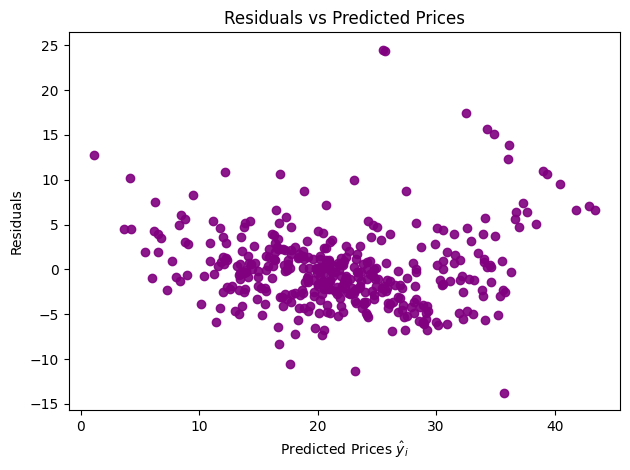

In [ ]:
plt.scatter(predicted_values, residuals, color='purple', alpha=0.9)
# plt.plot([y_train.min(), y_train.max()],
#          [y_train.min(), y_train.max()],
#          color='cyan', linestyle='-')

plt.xlabel(r"Predicted Prices $\hat{y}_i$")
plt.ylabel(r"Residuals")
plt.title(r"Residuals vs Predicted Prices")

plt.tight_layout()
plt.show()

Why do I want to look at the residuals? I want to check that they look random. Why? The residuals represent the errors of our model. If there's a pattern in our errors, then our model has a systematic bias.

We can analyse the distribution of the residuals. In particular, we're interested in the **skew** and the **mean**.

In an ideal case, what we want is something close to a normal distribution. A normal distribution has a skewness of 0 and a mean of 0. A skew of 0 means that the distribution is symmetrical - the bell curve is not lopsided or biased to one side. Here's what a normal distribution looks like:

<img src=https://i.imgur.com/7QBqDtO.png height=400>

I will:
* Calculate the mean and the skewness of the residuals.
* Again, use Seaborn's `.displot()` to create a histogram and superimpose the Kernel Density Estimate (KDE)
* Is the skewness different from zero? If so, by how much?
* Is the mean different from zero?

In [ ]:
residuals.mean()

np.float64(6.9471381342881085e-16)

In [ ]:
residuals.skew()

np.float64(1.4594428196679727)

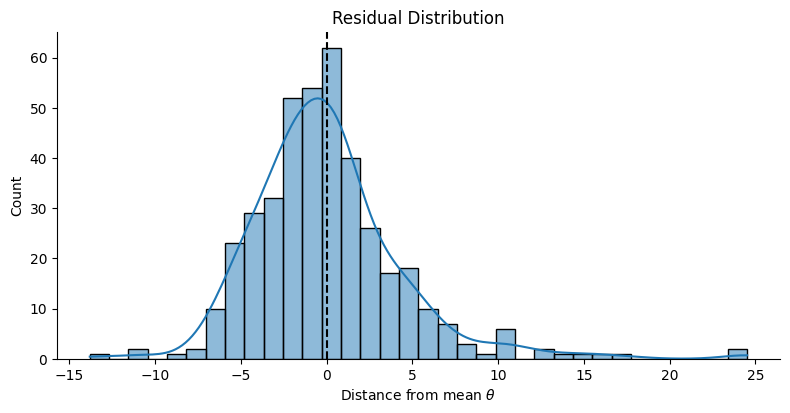

In [ ]:
sns.displot(residuals, kde=True, height=4, aspect=2)
plt.axvline(0, color='black', linestyle='--')
plt.xlabel(r'Distance from mean $\theta$')
plt.title("Residual Distribution")
plt.show()




### Data Transformations for a Better Fit

I have two options at this point:

1. Change my model entirely. Perhaps a linear model is not appropriate.
2. Transform my data to make it fit better with our linear model.

Let's try a data transformation approach.

I will Investigate if the target `data['PRICE']` could be a suitable candidate for a log transformation and

* Use Seaborn's `.displot()` to show a histogram and KDE of the price data.
* Calculate the skew of that distribution.
* Use [NumPy's `log()` function](https://numpy.org/doc/stable/reference/generated/numpy.log.html) to create a Series that has the log prices
* Plot the log prices using Seaborn's `.displot()` and calculate the skew.
* Which distribution has a skew that's closer to zero?


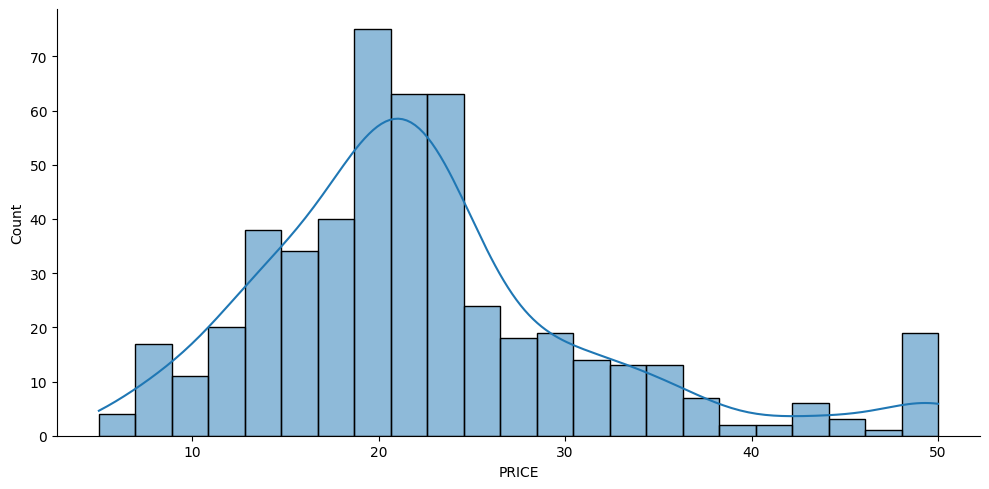

In [ ]:
sns.displot(data=data, x='PRICE', kde=True, aspect=2)


In [ ]:
data.PRICE.skew()

np.float64(1.1080984082549072)

In [ ]:
log_prices = np.log(data.PRICE)
log_prices

,PRICE
0,3.18
1,3.07
2,3.55
3,3.51
4,3.59
...,...
501,3.11
502,3.03
503,3.17
504,3.09


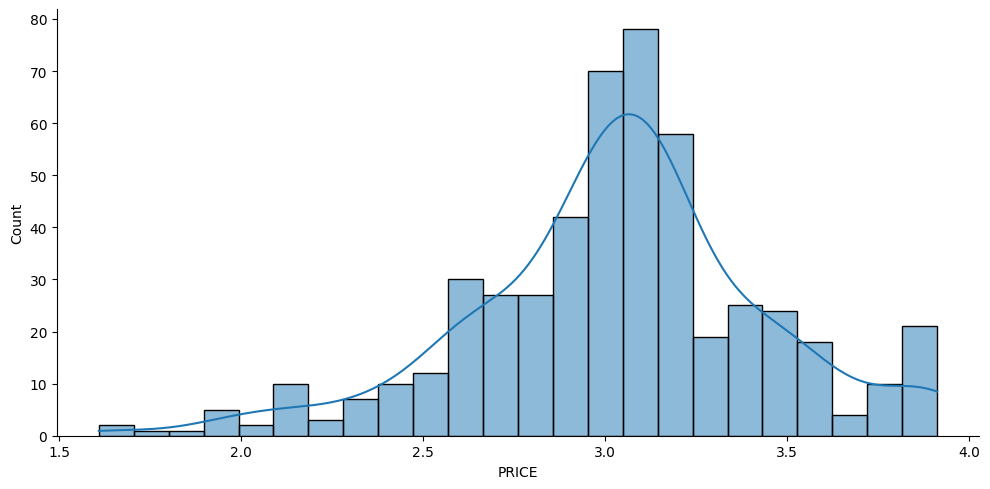

In [ ]:
sns.displot(data=log_prices, kde=True, aspect=2)

In [ ]:
# Skew:
log_prices.skew()
print('The log-transformed prices have a skew closer to zero (–0.33), so they are more normally distributed than the original prices.')
print('The log transformation improves symmetry and reduces skewness.')

The log-transformed prices have a skew closer to zero (–0.33), so they are more normally distributed than the original prices.
The log transformation improves symmetry and reduces skewness.


#### How does the log transformation work?

Using a log transformation does not affect every price equally. Large prices are affected more than smaller prices in the dataset. Here's how the prices are "compressed" by the log transformation:

<img src=https://i.imgur.com/TH8sK1Q.png height=200>

I can see this when I plot the actual prices against the (transformed) log prices.

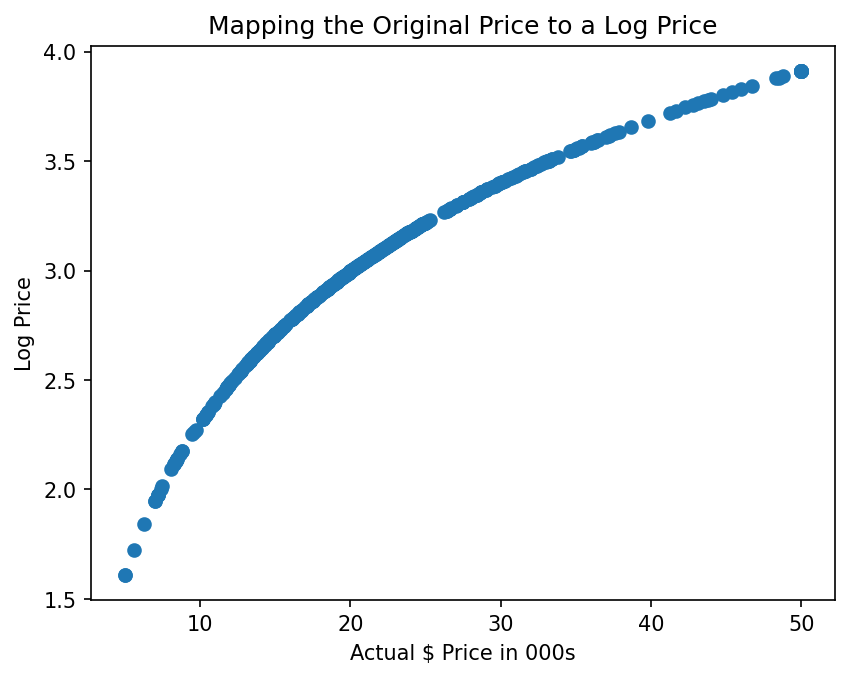

In [ ]:
plt.figure(dpi=150)
plt.scatter(data.PRICE, np.log(data.PRICE))

plt.title('Mapping the Original Price to a Log Price')
plt.ylabel('Log Price')
plt.xlabel('Actual $ Price in 000s')
plt.show()

## Regression using Log Prices

Using log prices instead, my model has changed to:

$$ \log (PR \hat ICE) = \theta _0 + \theta _1 RM + \theta _2 NOX + \theta_3 DIS + \theta _4 CHAS + ... + \theta _{13} LSTAT $$

I will:

* Use `train_test_split()` with the same random state as before to make the results comparable.
* Run a second regression, but this time use the transformed target data.
* What is the r-squared of the regression on the training data?
* Have we improved the fit of our model compared to before based on this measure?


In [ ]:
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X, log_prices, test_size=0.20, random_state=10
)

reg_2 = LinearRegression().fit(X_train_log, y_train_log)

y_pred_log = reg_2.predict(X_test_log)

mse_2 = mean_squared_error(y_test_log, y_pred_log)
r2_2 = r2_score(y_test_log, y_pred_log)

print("R² on training data:", reg_2.score(X_train_log, y_train_log))
print("Test MSE:", mse_2)
print("Test R²:", r2_2)

R² on training data: 0.7930234826697584
Test MSE: 0.04260094692201378
Test R²: 0.7446922306260739


In [ ]:
print('The log transformation produces a more linear relationship between the predictors and the target variable.')
print('Since linear regression assumes linearity, the transformed data better satisfies model assumptions.')
print('As a result, the model explains more variance (higher R²) and generalizes better on test data.')

The log transformation produces a more linear relationship between the predictors and the target variable.
Since linear regression assumes linearity, the transformed data better satisfies model assumptions.
As a result, the model explains more variance (higher R²) and generalizes better on test data.


## Evaluating Coefficients with Log Prices

I will print out the coefficients of the new regression model.

* Do the coefficients still have the expected sign?
* Is being next to the river a positive based on the data?
* How does the quality of the schools affect property prices? What happens to prices as there are more students per teacher?

I will use a DataFrame to make the output look pretty.

In [ ]:
reg_2.coef_

array([-1.06717261e-02,  1.57929102e-03,  2.02989827e-03,  8.03305301e-02,
       -7.04068057e-01,  7.34044072e-02,  7.63301755e-04, -4.76332789e-02,
        1.45651350e-02, -6.44998303e-04, -3.47947628e-02,  5.15896157e-04,
       -3.13900565e-02])

In [ ]:
log_coef_df = pd.DataFrame(
    data=reg_2.coef_,
    index=X.columns,
    columns=['Coefficient']
)
log_coef_df




,Coefficient
CRIM,-0.01
ZN,0.00
INDUS,0.00
CHAS,0.08
NOX,-0.70
RM,0.07
AGE,0.00
DIS,-0.05
RAD,0.01
TAX,-0.00


In [ ]:
# Do the coefficients still have the expected sign?
print('Signs are correct and meaningful.\n')

# Is being next to the river a positive based on the data?
river_coef = log_coef_df.loc['CHAS'].values[0]
print(f'Yes. It is positive. Being near the river increases prices by {river_coef *100:.0f}%\n')

# How does the quality of the schools affect property prices?
ptratio_coef = log_coef_df.loc['PTRATIO'].values[0]
print(f"School quality strongly impacts housing prices: a higher student–teacher ratio decreases prices by {abs(ptratio_coef * 100):.0f}%\n")

Signs are correct and meaningful.

Yes. It is positive. Being near the river increases prices by 8%

School quality strongly impacts housing prices: a higher student–teacher ratio decreases prices by 3%



## Regression with Log Prices & Residual Plots

* I will copy-paste the cell where I've created scatter plots of the actual versus the predicted home prices as well as the residuals versus the predicted values.
* Add 2 more plots to the cell so that you can compare the regression outcomes with the log prices side by side.
* Use `indigo` as the colour for the original regression and `navy` for the color using log prices.

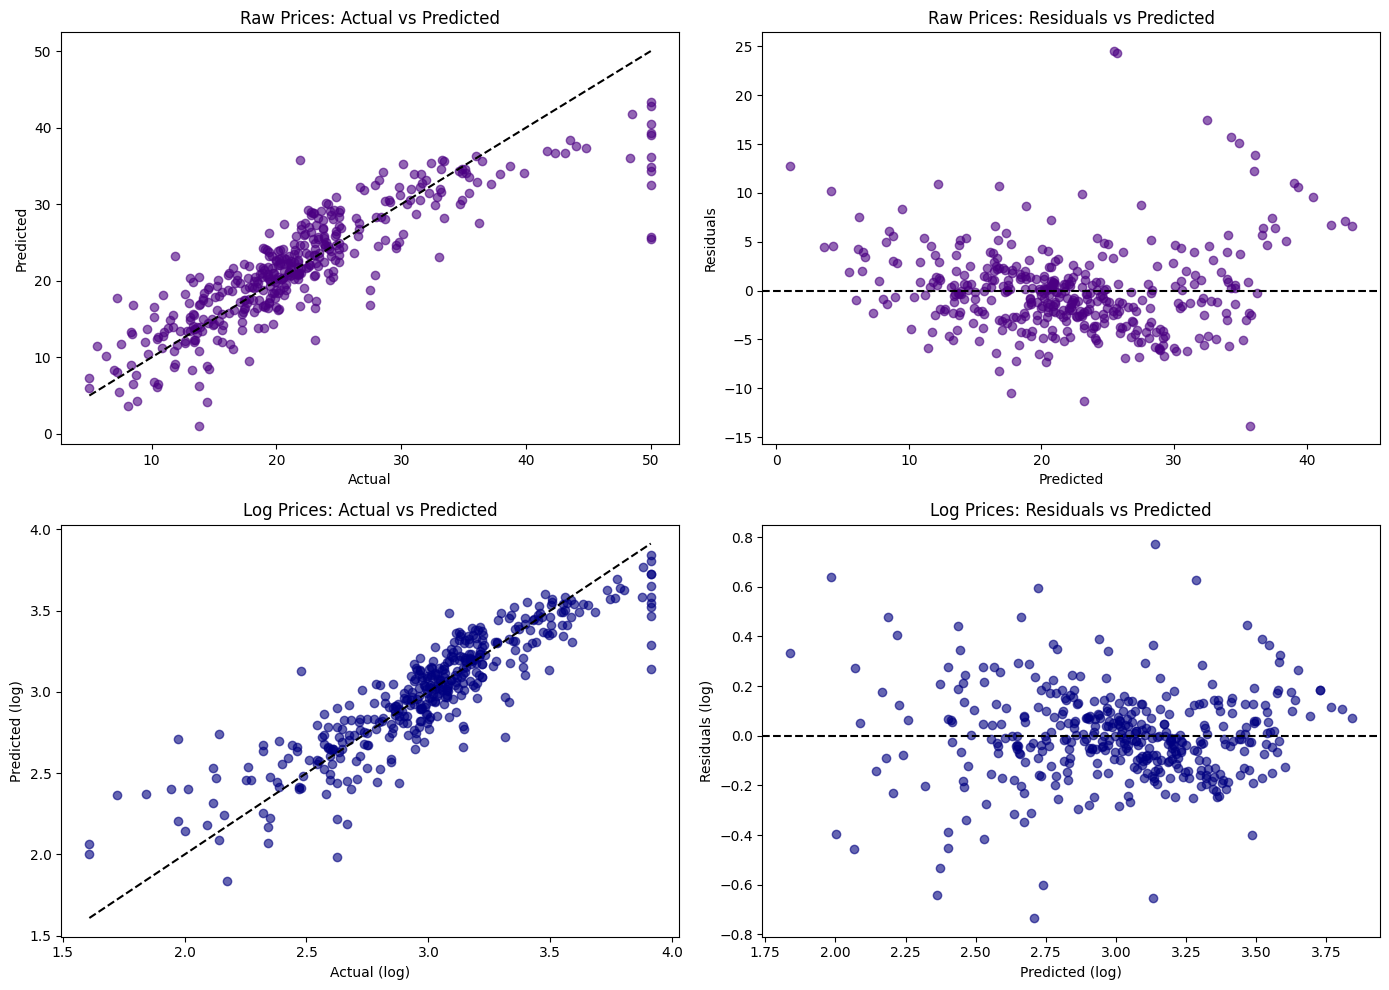

In [ ]:
# Actual vs Predicted

# Original model
y_pred_train = reg.predict(X_train)
residuals = y_train - y_pred_train

# Log price model
y_pred_train_log = reg_2.predict(X_train_log)
residuals_log = y_train_log - y_pred_train_log

# 2x2 Plot Layout
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Actual vs Predicted (raw)
axes[0, 0].scatter(y_train, y_pred_train, alpha=0.6, color='indigo')
axes[0, 0].plot([y_train.min(), y_train.max()],
                [y_train.min(), y_train.max()],
                linestyle='--', color='black')
axes[0, 0].set_title("Raw Prices: Actual vs Predicted")
axes[0, 0].set_xlabel("Actual")
axes[0, 0].set_ylabel("Predicted")

# -----------------------------
# 2) Residuals vs Predicted (raw)
axes[0, 1].scatter(y_pred_train, residuals, alpha=0.6, color='indigo')
axes[0, 1].axhline(0, linestyle='--', color='black')
axes[0, 1].set_title("Raw Prices: Residuals vs Predicted")
axes[0, 1].set_xlabel("Predicted")
axes[0, 1].set_ylabel("Residuals")

# -----------------------------
# 3) Actual vs Predicted (log prices)
axes[1, 0].scatter(y_train_log, y_pred_train_log, alpha=0.6, color='navy')
axes[1, 0].plot([y_train_log.min(), y_train_log.max()],
                [y_train_log.min(), y_train_log.max()],
                linestyle='--', color='black')
axes[1, 0].set_title("Log Prices: Actual vs Predicted")
axes[1, 0].set_xlabel("Actual (log)")
axes[1, 0].set_ylabel("Predicted (log)")

# -----------------------------
# 4) Residuals vs Predicted (log prices)
axes[1, 1].scatter(y_pred_train_log, residuals_log, alpha=0.6, color='navy')
axes[1, 1].axhline(0, linestyle='--', color='black')
axes[1, 1].set_title("Log Prices: Residuals vs Predicted")
axes[1, 1].set_xlabel("Predicted (log)")
axes[1, 1].set_ylabel("Residuals (log)")

plt.tight_layout()
plt.show()

I will calculate the mean and the skew for the residuals using log prices. Are the mean and skew closer to 0 for the regression using log prices?

In [ ]:
residuals_log.skew()

np.float64(0.09299942594123424)

In [ ]:
residuals_log.mean()

np.float64(-4.7816536209103276e-17)

# Compare Out of Sample Performance

The *real* test is how my model performs on data that it has not "seen" yet. This is where our `X_test` comes in.

I will compare the r-squared of the two models on the test dataset. Which model does better? Is the r-squared higher or lower than for the training dataset? Why?

In [ ]:
# Original Model
y_pred_train = reg.predict(X_train)
y_pred_test = reg.predict(X_test)

train_r2_score = r2_score(y_train, y_pred_train)
test_r2_score = r2_score(y_test, y_pred_test )

# Log Model
y_pred_train_log = reg_2.predict(X_train_log)
y_pred_test_log = reg_2.predict(X_test_log)

train_r2_score_log = r2_score(y_train_log, y_pred_train_log)
test_r2_score_log = r2_score(y_test_log, y_pred_test_log )

In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["Original Prices", "Log Prices"],
    "Train R²": [train_r2_score, train_r2_score_log],
    "Test R²": [test_r2_score,  test_r2_score_log]
})

comparison_df


,Model,Train R²,Test R²
0,Original Prices,0.75,0.67
1,Log Prices,0.79,0.74


# Predict a Property's Value using the Regression Coefficients

My preferred model now has an equation that looks like this:

$$ \log (PR \hat ICE) = \theta _0 + \theta _1 RM + \theta _2 NOX + \theta_3 DIS + \theta _4 CHAS + ... + \theta _{13} LSTAT $$

The average property has the mean value for all its charactistics:

In [ ]:
# Starting Point: Average Values in the Dataset
features = data.drop(['PRICE'], axis=1)
average_vals = features.mean().values
property_stats = pd.DataFrame(data=average_vals.reshape(1, len(features.columns)),
                              columns=features.columns)
property_stats

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65


I will predict how much the average property is worth using the stats above. What is the log price estimate and what is the dollar estimate? I will [reverse the log transformation with `.exp()`](https://numpy.org/doc/stable/reference/generated/numpy.exp.html?highlight=exp#numpy.exp) to find the dollar value.

In [ ]:
intercept = reg_2.intercept_
coefs = reg_2.coef_
theta = np.insert(coefs, 0, intercept)

x = np.insert(property_stats.values[0], 0, 1)
x.shape

log_price = np.dot(x, theta)
log_price

dollar_estimate = np.exp(log_price)

log_price, dollar_estimate

(np.float64(3.030287230563396), np.float64(20.703178321023934))

In [ ]:
x

array([1.00000000e+00, 3.61352356e+00, 1.13636364e+01, 1.11367787e+01,
       6.91699605e-02, 5.54695059e-01, 6.28463439e+00, 6.85749012e+01,
       3.79504269e+00, 9.54940711e+00, 4.08237154e+02, 1.84555336e+01,
       3.56674032e+02, 1.26530632e+01])

Keeping the average values for CRIM, RAD, INDUS and others, value a property with the following characteristics:

In [ ]:
# Define Property Characteristics
next_to_river = True
nr_rooms = 8
students_per_classroom = 20
distance_to_town = 5
pollution = data.NOX.quantile(q=0.75) # high
amount_of_poverty =  data.LSTAT.quantile(q=0.25) # low

In [ ]:
# Solution:
house = property_stats.copy()

house['CHAS'] = 1 if next_to_river else 0
house['RM'] = nr_rooms
house['PTRATIO'] = students_per_classroom
house['DIS'] = distance_to_town
house['NOX'] = pollution
house['LSTAT'] = amount_of_poverty

x = house.values[0]

log_price_pred = reg_2.predict([x])[0]
price_pred = np.exp(log_price_pred)

print(log_price_pred, price_pred)




3.250065369440925 25.792025872399094


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

